----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
spinful                     = False
number of spin components   = 1
number of electronic states = 2
number of orbitals          = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]

Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
----------------------------------------
Site energies:
  < 0 | H | 0 > = -0.000 
  < 1 | H | 1 > =  0.000 
Hoppings:
  < 0 | H | 1  + [ 0.0 ,  0.0 ] > = -1.0000+0.0000j
  < 1 | H | 0  + [ 1.0 , 

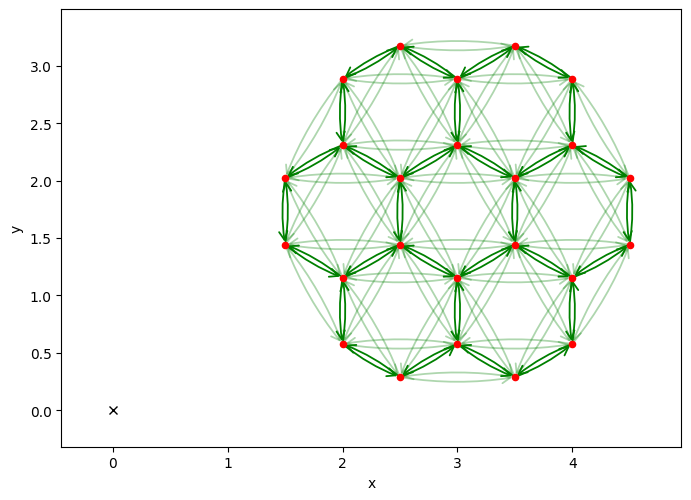

In [369]:
#Haldane model, only modeling pz C orbitals 
from pythtb import *
import numpy as np
import TBLR2 as TBLR
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# define lattice vectors
lat_vecs = [[1, 0], [1 / 2, np.sqrt(3) / 2]]
# define coordinates of orbitals
orb_vecs = [[1 / 3, 1 / 3], [2 / 3, 2 / 3]]
lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=...)

# make two dimensional tight-binding Haldane model
haldane = TBModel(lat)

# set model parameters
delta = 0.0
t = -1.0
t2 = 0.15 * np.exp(1j * np.pi / 2)
t2c = t2.conjugate()

# set on-site energies
haldane.set_onsite([-delta, delta])
# set hoppings (one for each connected pair of orbitals)
# (amplitude, i, j, [lattice vector to cell containing j])
haldane.set_hop(t, 0, 1, [0, 0])
haldane.set_hop(t, 1, 0, [1, 0])
haldane.set_hop(t, 1, 0, [0, 1])
# add second neighbour complex hoppings
haldane.set_hop(t2, 0, 0, [1, 0])
haldane.set_hop(t2, 1, 1, [1, -1])
haldane.set_hop(t2, 1, 1, [0, 1])
haldane.set_hop(t2c, 1, 1, [1, 0])
haldane.set_hop(t2c, 0, 0, [1, -1])
haldane.set_hop(t2c, 0, 0, [0, 1])

print(haldane)

#make supercell for benzene
supercell_1 = haldane.make_supercell(np.array([[2,0],[0,2]]))
benzene = supercell_1.cut_piece(1, 1, glue_edges=False) #make it non-periodic in both directions
benzene = benzene.cut_piece(1, 0, glue_edges=False)
benzene.remove_orb(7)
benzene.remove_orb(0)

#Make large enough supercell to hold coronene
supercell_2 = haldane.make_supercell(np.array([[4,0],[0,4]]))
coronene = supercell_2.cut_piece(1, 1, glue_edges=False) #make it non-periodic in both directions
coronene = coronene.cut_piece(1, 0, glue_edges=False)

#Get these orbitals from plotting orbitals individually.. Don't combine remove to a list of orbitals, it gives error. 
coronene.remove_orb(31)
coronene.remove_orb(30)
coronene.remove_orb(29)
coronene.remove_orb(23)
coronene.remove_orb(8)
coronene.remove_orb(2)
coronene.remove_orb(1)
coronene.remove_orb(0)
#31,30,29,23,8,2,1,0
coronene.visualize()
print(coronene)

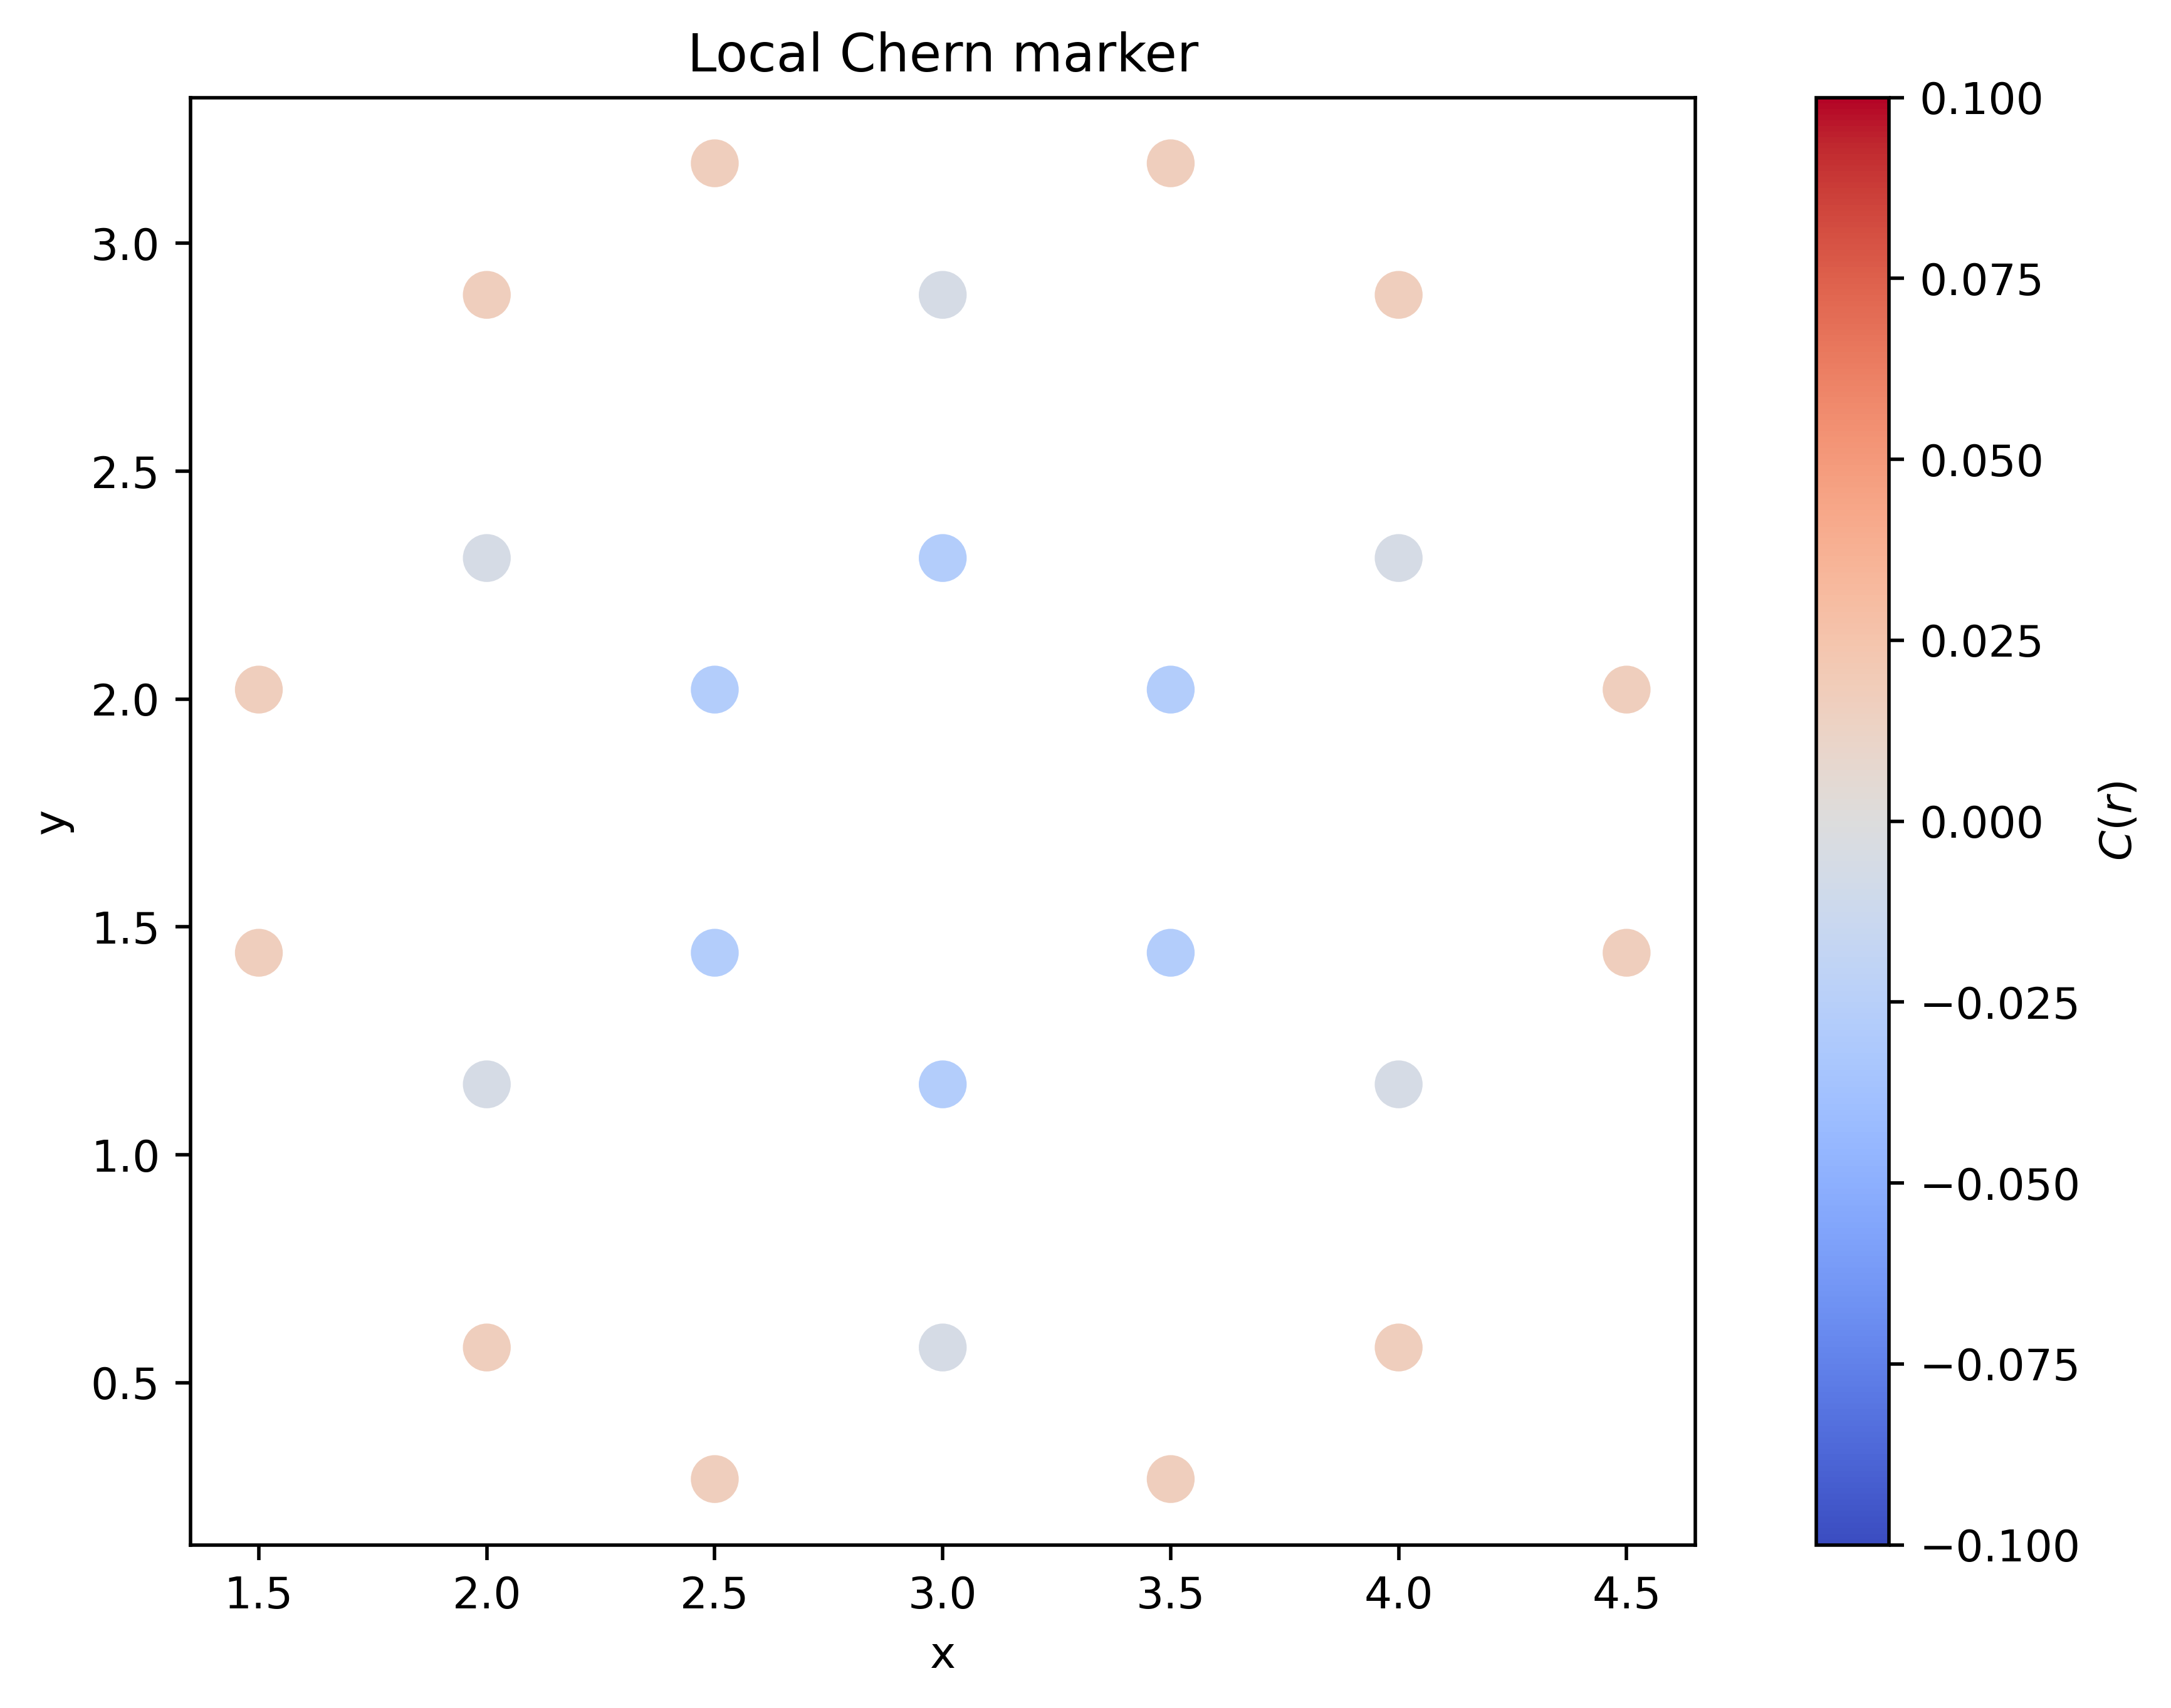

In [370]:
#pythTB manner of computing local chern marker.. 
C_local, C_bulk_avg =coronene.local_chern_marker(return_bulk_avg = True,trim_cells=0)
fig, ax = plt.subplots(figsize=(10, 6), dpi=500)
pos = coronene.get_orb_vecs(cartesian=True)
sc = ax.scatter(
    pos[:, 0],
    pos[:, 1],
    c=C_local,
    s=100,
    cmap="coolwarm",
    vmin=-0.1,
    vmax=0.1,
)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Local Chern marker")
fig.colorbar(sc, ax=ax, label=r"$C(r)$")

In [371]:
#Choose the model here 
my_model = haldane#benzene, coronene, haldane
if my_model==benzene or my_model == coronene:  #different calc for molecules
    molecule = True
else:
    molecule = False

#Put it in format that works with Nish's code. 
#Need to change from PythTB model because we need "natural embedding"
H = np.empty((my_model.norb,my_model.norb), dtype=object)
for i in range(len(H)):
    for j in range(len(H)):
        H[i,j] = []
orb_pos = my_model.orb_vecs
abs_dist_list = []
t_list=[]
for hop in my_model.hoppings:
    if len(hop)==3: #if j image is [0,0] pythTB doesn't return it. 
        t = hop['amplitude']
        i = hop['from_orbital']
        j = hop['to_orbital']
        j_image = np.array([0,0])
        #print(t,i,j,j_image)
    else:
        t = hop['amplitude']
        i = hop['from_orbital']
        j = hop['to_orbital']
        j_image = hop['lattice_vector']
       # print(t,i,j,j_image)
    dist = ((orb_pos[j]+j_image)-orb_pos[i])@my_model.get_lat()
    print("dsize",np.linalg.norm(dist))
    print("dist",dist)
    abs_dist = np.linalg.norm(dist)
    abs_dist_list.append(abs_dist)
    t_list.append(t)
    H[i,j].append([t,dist[0],dist[1]])

#Function that finds hamiltonian from hopping array at specific k-point
def ham_func(k):
    kx,ky=k
    H_res = np.zeros((my_model.norb,my_model.norb),dtype = complex)
    for i in np.arange(0,my_model.norb,1):
        for j in np.arange(0,my_model.norb):
            if len(H[i][j]) == 0:
                pass 
            else:
                for item in H[i][j]:
                    item0=complex(item[0])
                    item1=complex(item[1])
                    item2=complex(item[2])
                    H_res[i][j] += np.round(item0,10)*(np.exp(1j* kx *item1+ 1j* ky *item2))
                    H_res[j][i] += np.conj(np.round(item0,10)*(np.exp(1j* kx *item1+ 1j* ky *item2)))
    for i,onsite in enumerate(my_model._site_energies):
        H_res[i,i]+=np.round(onsite,10)
    return H_res

dsize 0.5773502691896257
dist [0.5        0.28867513]
dsize 0.5773502691896257
dist [ 0.5        -0.28867513]
dsize 0.5773502691896257
dist [0.         0.57735027]
dsize 1.0
dist [1. 0.]
dsize 0.9999999999999999
dist [ 0.5       -0.8660254]
dsize 0.9999999999999998
dist [0.5       0.8660254]
dsize 0.9999999999999999
dist [1. 0.]
dsize 0.9999999999999999
dist [ 0.5       -0.8660254]
dsize 0.9999999999999999
dist [0.5       0.8660254]


/var/folders/ng/x4d83h9x2_5199m7r89f1gwr0000gn/T/ipykernel_86294/68161877.py:30: FutureWarning: TBModel.get_lat is deprecated and will be removed in a future release: Use 'get_lat_vecs' instead.
  dist = ((orb_pos[j]+j_image)-orb_pos[i])@my_model.get_lat()


/var/folders/ng/x4d83h9x2_5199m7r89f1gwr0000gn/T/ipykernel_86294/2423583339.py:4: FutureWarning: TBModel.get_lat is deprecated and will be removed in a future release: Use 'get_lat_vecs' instead.
  lat = my_model.get_lat()


occ 1


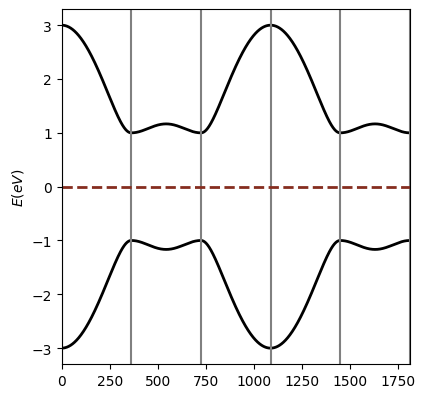

In [372]:
#Make tight-binding object in Nish's code
nkpx=100
nkpy=100
lat = my_model.get_lat()
tb = TBLR.TBLinearResponse(ham_func, Lar=np.array(lat), 
                           Nkp=[nkpx,nkpy],    # the first entry is number of points for line cuts and second entry is mesh size (200x200)
                           prestr='Diamond_super',   # Not using for this 
                           save_all=False,   # Not using
                           kpath = ['G', 'X', 'M', 'G','Y','M'],   # high symmetry path for band structure plots   
                           )
mu=0 
occ = int(len(tb.enUM[0,:,0][tb.enUM[0,:,0]<=mu])) #sum bands below mu at gamma point to get occupation.

print("occ",occ)
evals, evecs,klabels= tb.solve_alongpath() 
evecs = np.array(evecs)
plt.plot(evals, 'k',linewidth=2)

k_index = np.arange(0,np.shape(evals)[0])

plt.xlim(klabels[0],klabels[-1])
plt.ylabel(r'$E (eV)$')
for k in klabels:
    plt.axvline(k,color="grey")
plt.axhline(mu,linestyle="dashed",color="#852D1F",linewidth=2)
plt.tight_layout()
plt.gcf().set_size_inches(4, 4)
#plt.savefig(wann_dir+"/2x2x2_band.png",dpi=400,bbox_inches='tight')  


In [ ]:
tau = my_model.get_orb()
print(tau)
print(tb.Lar)
print(my_model.get_lat())

threshold = 0

def bond_element(tb, occ, R,molecule=molecule):
    if molecule:
        en, um= TBLR.eigenstates(tb.ham(k=[0,0]))     #Ham at zero.. 
        u=um[:,:occ]                     # get only filled states
        rho_k_bd = u @ u.conj().T      # not doing anything with spin..
        tau_lat = tau @ tb.Lar
        r_bd = tau_lat[np.newaxis, :] - tau_lat[:, np.newaxis]   # no R for a molecule
        return rho_k_bd, r_bd
        
    elif molecule ==False:
        kpts = tb.kSpan
        um = tb.enUM[:, :, 1:occ+1]
        R_lat = R @ tb.Lar 
        tau_lat = tau @ tb.Lar
        r_bd = tau_lat[np.newaxis, :] - tau_lat[:, np.newaxis]+R_lat
        val = 0.0 + 0.0j
        for ik, k in enumerate(kpts):
            u = um[ik]
            rho_k_bd = u@ u.conj().T # not doing anything with spin..
            phase = np.exp(-1.j * np.einsum("k,bdk->bd",k,r_bd))
            #print("phase",phase)
            val += (rho_k_bd * phase)
        return (val / len(kpts)),r_bd
    
def QGT_from_bonding(R_list):
    vol = np.linalg.det(tb.Lar) #volume/area of unit cell
    pref = (2*np.pi*occ)/vol
    total = 0.0
    chunks   = [] 
    for R1 in tqdm(R_list):
        for R2 in R_list:
            R1 = np.array(R1)
            R2 = np.array(R2)
            R3 = -R1-R2 #complete the loop?
            #print("R1",R1,"R2",R2)
            rho_ab, dist_ab = bond_element(tb, occ=occ, R=R1)
            rho_bc, dist_bc = bond_element(tb, occ=occ, R=R2)
            rho_ca, dist_ca = bond_element(tb, occ=occ, R=R3)
            
            BI = np.einsum("ab,bc,ca->abc",rho_ab,rho_bc,rho_ca) #three-center bond index
            x_ba = -dist_ab[:,:,0] ;y_ba = -dist_ab[:,:,1]
            x_ca = dist_ca[:,:,0] ;y_ca= dist_ca[:,:,1]
            dist_part_1 = np.einsum("ba,ca->abc",x_ba,y_ca)
            dist_part_2 = -np.einsum("ba,ca->abc",y_ba,x_ca)
            dist_part = dist_part_1+dist_part_2
            total += pref*dist_part * BI

            mask = np.abs(dist_part*BI) > threshold
            #print("mask",np.shape(mask))
            if not mask.any():
                continue
            ai, bi, ci = np.where(mask)
            vals = BI[mask]
            dist_p1 = dist_part_1[mask]
            dist_p2 = dist_part_2[mask]
            dist_tot = dist_part[mask]
            chunks.append(pd.DataFrame({                        
                "a": ai, "b": bi, "c": ci,
                "R1x": R1[0],
                "R1y": R1[1],
                "R2x": R2[0],
                "R2y": R2[1],
                "dist_ab_x": x_ba[ai,bi],
                "dist_ab_y": y_ba[ai,bi],
                "dist_ca_x": x_ca[ci,ai],
                "dist_ca_y": y_ca[ci,ai],
                "dist_part_1":dist_p1,
                "dist_part_2":dist_p2,
                "dist_part":dist_tot,
                "BI_real": vals.real, 
                "BI_imag": vals.imag, 
                "BI_abs": np.abs(vals),
                "C_real": (pref * dist_tot * vals.real),   
                "C_imag": (pref * dist_tot * vals.imag),  
            }))

    print("total",np.sum(total))   
    
    return chunks
    

[[0.33333333 0.33333333]
 [0.66666667 0.66666667]]
[[1.        0.       ]
 [0.5       0.8660254]]
[[1.        0.       ]
 [0.5       0.8660254]]


/var/folders/ng/x4d83h9x2_5199m7r89f1gwr0000gn/T/ipykernel_86294/191396388.py:1: FutureWarning: TBModel.get_orb is deprecated and will be removed in a future release: Use 'get_orb_vecs' instead.
  tau = my_model.get_orb()
/var/folders/ng/x4d83h9x2_5199m7r89f1gwr0000gn/T/ipykernel_86294/191396388.py:4: FutureWarning: TBModel.get_lat is deprecated and will be removed in a future release: Use 'get_lat_vecs' instead.
  print(my_model.get_lat())


In [381]:
R_list=[]
R_x = np.arange(-4,5,1)
R_y = R_x
for i in R_x:
    for j in R_y:
        R_list.append([i,j]) 
#use R = [0,0] for molecules 
#R_list = np.array([[0,0]]) #for molecules
print(R_list)
df1= QGT_from_bonding(R_list)

df = (pd.concat(df1, ignore_index=True) if df1 else pd.DataFrame())#.sort_values("C_imag", ascending=False, ignore_index=True)
df.to_csv("/Users/gcarrel/Princeton Dropbox/Gabrielle Carrel/Laptop_Backup/SCHOOP/Distorted_Square_Net/haldane/new_values/haldane.csv", index=False)

[[np.int64(-4), np.int64(-4)], [np.int64(-4), np.int64(-3)], [np.int64(-4), np.int64(-2)], [np.int64(-4), np.int64(-1)], [np.int64(-4), np.int64(0)], [np.int64(-4), np.int64(1)], [np.int64(-4), np.int64(2)], [np.int64(-4), np.int64(3)], [np.int64(-4), np.int64(4)], [np.int64(-3), np.int64(-4)], [np.int64(-3), np.int64(-3)], [np.int64(-3), np.int64(-2)], [np.int64(-3), np.int64(-1)], [np.int64(-3), np.int64(0)], [np.int64(-3), np.int64(1)], [np.int64(-3), np.int64(2)], [np.int64(-3), np.int64(3)], [np.int64(-3), np.int64(4)], [np.int64(-2), np.int64(-4)], [np.int64(-2), np.int64(-3)], [np.int64(-2), np.int64(-2)], [np.int64(-2), np.int64(-1)], [np.int64(-2), np.int64(0)], [np.int64(-2), np.int64(1)], [np.int64(-2), np.int64(2)], [np.int64(-2), np.int64(3)], [np.int64(-2), np.int64(4)], [np.int64(-1), np.int64(-4)], [np.int64(-1), np.int64(-3)], [np.int64(-1), np.int64(-2)], [np.int64(-1), np.int64(-1)], [np.int64(-1), np.int64(0)], [np.int64(-1), np.int64(1)], [np.int64(-1), np.int64(2)

100%|██████████| 81/81 [10:17<00:00,  7.62s/it]


total (-4.901210910202953e-15-0.9978440331229724j)


In [ ]:
np.sum(df['C_imag']) #should be -1 for haldane.. (-0.9978440331229732)

np.float64(-0.9978440331229732)